# 02 — Spike Definition and Rate Estimation

Research question 2 asks whether a price spike can be predicted *before* it happens. That
requires a spike to be defined operationally, and the definition inherited from the
literature cannot simply be adopted — it was built for a different kind of series.

This notebook:

1. Establishes what constitutes a single flight's price trajectory.
2. Characterises how fares actually move along one, which turns out to differ sharply from
   the commodity-price series the spike definition was borrowed from.
3. Tunes the rolling-window size empirically instead of inheriting it.
4. Distinguishes spike *events* from sustained elevated *states* — a distinction that
   materially changes what a model would be asked to learn.
5. Produces the first real spike-rate estimate, which determines the class-imbalance
   strategy.

**Sample restriction.** Departures after 12 October 2022 are right-censored (notebook 01,
§7.1): scraping stopped on 5 October, so late departures were never observed near departure,
which is exactly where fare surges occur. They are excluded here. Retaining them would bias
the spike rate downward — those flights would appear spike-free because nobody was looking,
not because their fares were stable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from flightprice.config import (
    PROCESSED_DIR, FULL_TRAJECTORY_END, SPIKE_SIGMA,
    SPIKE_WINDOW, SPIKE_MIN_PERIODS, set_seeds,
)
from flightprice.plotting import set_plot_style, save_fig, PALETTE
from flightprice.spikes.labelling import (
    add_days_before_departure, add_rolling_stats, label_spikes,
    spike_summary, sweep_windows,
)

set_seeds()
set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

In [2]:
full = pd.read_parquet(PROCESSED_DIR / "coach_filtered.parquet")

df = full[full["flightDate"].dt.date <= FULL_TRAJECTORY_END].copy()
df = add_days_before_departure(df)

print(f"all coach rows          : {len(full):,}")
print(f"after censoring cutoff  : {len(df):,}  ({len(df)/len(full):.1%})")
print(f"cutoff applied          : flightDate <= {FULL_TRAJECTORY_END}")
print(f"distinct flights (legId): {df['legId'].nunique():,}")

all coach rows          : 2,152,628
after censoring cutoff  : 1,943,082  (90.3%)
cutoff applied          : flightDate <= 2022-10-12
distinct flights (legId): 106,700


## 1. What is a single flight's price trajectory?

A spike is defined relative to a flight's own recent price history, so the first requirement
is an identifier that follows one specific itinerary across successive searches. `legId` is
the candidate. Two properties must hold: it must recur across search dates (otherwise there
is no trajectory), and it must map to exactly one departure (otherwise it is aggregating
distinct flights).

In [3]:
# STEP 1: check the data is shaped the way we think it is, before trusting it.
#
# A 'legId' is supposed to identify one specific flight. Everything in this
# notebook depends on that being true, so we check rather than assume:
#   - is each flight priced more than once?  (needed to have a history at all)
#   - does any legId cover two departure dates?  (would mean it is not one flight)
#   - are there duplicate rows for the same flight on the same day?
# The answers came back clean, so no de-duplication was needed.
per_leg = df.groupby("legId", observed=True).agg(
    observations=("searchDate", "nunique"),
    distinct_flightDates=("flightDate", "nunique"),
)

print(f"distinct legIds                      : {len(per_leg):,}")
print(f"legIds observed more than once       : {(per_leg.observations > 1).sum():,} "
      f"({(per_leg.observations > 1).mean():.1%})")
print(f"legIds spanning >1 departure date    : {(per_leg.distinct_flightDates > 1).sum():,}")
print(f"duplicate (legId, searchDate) rows   : {df.duplicated(['legId','searchDate']).sum():,}")
print()
print("observations per flight:")
print(per_leg.observations.describe().round(1).to_string())

distinct legIds                      : 106,700
legIds observed more than once       : 88,364 (82.8%)
legIds spanning >1 departure date    : 0


duplicate (legId, searchDate) rows   : 0

observations per flight:
count    106700.0
mean         18.2
std          18.8
min           1.0
25%           2.0
50%           9.0
75%          33.0
max          60.0


`legId` satisfies both conditions: no identifier spans more than one departure date, and
there is exactly one row per (flight, search date) pair, so a trajectory is well defined
without any deduplication.

The distribution of trajectory lengths is the first constraint on the rolling window. The
median flight is observed only **9 times**, while the upper quartile reaches 33 — so any
window longer than about ten observations will be unusable for more than half the flights.

In [4]:
coverage = pd.DataFrame({
    "flights_with_at_least": [(per_leg.observations >= n).sum() for n in (5,10,15,20,30,40,60)],
    "share_%": [(per_leg.observations >= n).mean()*100 for n in (5,10,15,20,30,40,60)],
}, index=pd.Index([5,10,15,20,30,40,60], name="observations")).round(1)
coverage

,flights_with_at_least,share_%
observations,,
5,68812,64.5
10,52885,49.6
15,43641,40.9
20,37605,35.2
30,29580,27.7
40,21479,20.1
60,577,0.5


## 2. Observation cadence

The window will be defined in *observations*. Whether that also corresponds to a fixed number
of days depends on how regularly each flight was searched — a question the research phase
flagged as open.

In [5]:
# How often were prices actually checked? Daily? Weekly? Irregularly?
#
# This matters because our spike window is defined in OBSERVATIONS, not days.
# A window of 10 observations only means '10 days' if prices were checked
# daily. .diff() gives the gap between one check and the next for each flight.
# Result: 85.8% of gaps are exactly 1 day, so the two are near enough the same.
d_sorted = df.sort_values(["legId", "searchDate"])
gaps = d_sorted.groupby("legId", observed=True)["searchDate"].diff().dt.days.dropna()

gap_table = pd.DataFrame({
    "count": gaps.value_counts().sort_index().head(7),
})
gap_table["share_%"] = (gap_table["count"] / len(gaps) * 100).round(2)
print(f"median gap: {gaps.median():.0f} day   mean gap: {gaps.mean():.2f} days")
print(f"gaps longer than 7 days: {(gaps > 7).sum():,} ({(gaps > 7).mean():.2%})")
gap_table

median gap: 1 day   mean gap: 1.52 days
gaps longer than 7 days: 33,845 (1.84%)


,count,share_%
searchDate,,
1.0,1576060,85.82
2.0,109543,5.97
3.0,60177,3.28
4.0,19127,1.04
5.0,22886,1.25
6.0,8435,0.46
7.0,6309,0.34


**85.8% of consecutive observations are exactly one day apart**, and gaps beyond a week are
under 2%. A window of *w* observations therefore spans approximately *w* days for the large
majority of flights, so the two framings largely coincide. This is worth stating explicitly
in the methodology rather than assuming it, since it is what makes the window size
interpretable in calendar terms at all.

## 3. How fares actually move

The spike definition is adapted from Lee et al. (2024), who applied a rolling 2σ rule to
daily metal-price closes. Whether that transfers depends on whether flight fares behave like
a comparable continuous series.

In [6]:
# THE FINDING THAT CHANGED THE PROJECT'S DESIGN.
#
# Here we ask a simple question: when the price is checked again, has it
# actually moved? .diff() gives the change since the previous check, so a
# change of exactly 0 means the fare did not budge.
#
# The answer is that 61.8% of the time it did not move at all, and a typical
# flight only ever shows 4 different prices across 9 checks. Fares are not a
# smooth wandering line -- they sit still in fixed bands and then jump.
#
# This is why the spike rule needed re-examining, and it is written up as a
# limitation: inside a flat run, ANY jump looks huge relative to a wobble of
# nearly zero.
changes = d_sorted.groupby("legId", observed=True)["totalFare"].diff()
unchanged = (changes == 0).sum()
moved = changes.notna().sum()

distinct_fares = df.groupby("legId", observed=True)["totalFare"].nunique()

print(f"consecutive observations with an IDENTICAL fare : {unchanged:,} / {moved:,} = {unchanged/moved:.1%}")
print(f"median distinct fares per flight                : {distinct_fares.median():.0f}")
print(f"median observations per flight                  : {per_leg.observations.median():.0f}")
print()
print("size of non-zero fare changes (USD):")
print(changes[changes != 0].abs().describe().round(2).to_string())

consecutive observations with an IDENTICAL fare : 1,134,398 / 1,836,382 = 61.8%
median distinct fares per flight                : 4
median observations per flight                  : 9

size of non-zero fare changes (USD):
count    701984.00
mean         59.26
std         105.81
min           0.01
25%          15.00
50%          35.01
75%          70.00
max        1501.00


This is the central finding of the notebook and it is not a minor technicality.

**Flight fares are step functions, not continuous series.** Nearly **62%** of consecutive
observations repeat the previous fare exactly, and a typical flight takes only **4 distinct
fare values across 9 observations**. Fares sit in quantised booking buckets and jump between
them.

The consequence for a rolling 2σ rule is direct: while a fare sits in a bucket the rolling
standard deviation collapses toward zero, so the *next* bucket change is almost guaranteed to
exceed two standard deviations regardless of its economic size. The threshold is measuring
bucket transitions, not unusual price movements. This is precisely why the window could not
be inherited unexamined, and it is a genuine methodological difference from the commodity
literature the definition came from.

saved -> reports/figures/02_example_trajectories.png


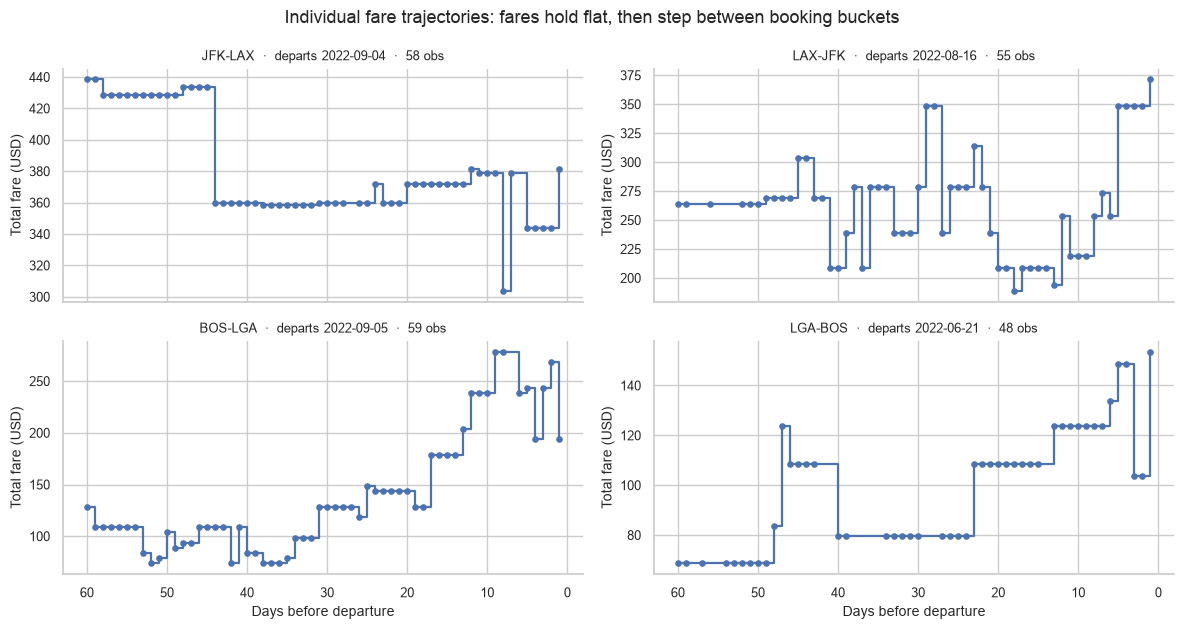

In [7]:
long_traj = per_leg[per_leg.observations >= 40].index
routes_of = df[df.legId.isin(long_traj)].groupby("legId", observed=True)["route"].first()

# one representative trajectory per route, so all four are visible
sample_flights = [
    routes_of[routes_of == r].index.to_series().sample(1, random_state=42).iloc[0]
    for r in ["JFK-LAX", "LAX-JFK", "BOS-LGA", "LGA-BOS"]
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)

for ax, leg in zip(axes.ravel(), sample_flights):
    t = df[df.legId == leg].sort_values("daysBeforeDeparture", ascending=False)
    ax.step(t.daysBeforeDeparture, t.totalFare, where="post", lw=1.6, color=PALETTE[0])
    ax.scatter(t.daysBeforeDeparture, t.totalFare, s=14, color=PALETTE[0], zorder=3)
    ax.set_title(f"{t.route.iloc[0]}  ·  departs {t.flightDate.iloc[0].date()}  ·  {len(t)} obs",
                 fontsize=9.5)
    ax.set_ylabel("Total fare (USD)")

# sharex=True means the x axis is shared: invert ONCE, not per subplot,
# so that time runs left to right and departure sits on the right edge.
axes[0, 0].invert_xaxis()

for ax in axes[1]:
    ax.set_xlabel("Days before departure")

fig.suptitle("Individual fare trajectories: fares hold flat, then step between booking buckets")
fig.tight_layout()
save_fig(fig, "02_example_trajectories")
plt.show()

The step structure is unmistakable in individual trajectories: long flat runs punctuated by
discrete jumps. Time runs left to right, so departure is at the right-hand edge.

Individual trajectories are noisy, so the aggregate booking curve is worth checking directly
rather than inferred from four examples.

In [8]:
# The booking curve: does the fare climb as departure gets closer?
#
# pd.cut sorts every price into a bucket by how far ahead it was seen
# (1-3 days, 4-7 days, and so on), then we take the average fare per bucket.
# The last row works out the total rise from the earliest bucket to the latest.
#
# The answer differs sharply by route, which is why this ended up mattering
# for research question 3: short-haul fares climb about 65% into departure,
# long-haul ones stay almost flat.
horizon_bins = [0, 3, 7, 14, 21, 30, 45, 61]
horizon_labels = ["1-3", "4-7", "8-14", "15-21", "22-30", "31-45", "46-60"]
hz = pd.cut(df.daysBeforeDeparture, horizon_bins, labels=horizon_labels)

booking_curve = df.groupby([hz, "route"], observed=True)["totalFare"].mean().unstack().round(1)
booking_curve.loc["rise 46-60 -> 1-3 (%)"] = (
    (booking_curve.loc["1-3"] / booking_curve.loc["46-60"] - 1) * 100
).round(1)
booking_curve

route,BOS-LGA,JFK-LAX,LAX-JFK,LGA-BOS
daysBeforeDeparture,,,,
1-3,213.4,423.9,450.6,211.9
4-7,183.9,407.4,450.3,186.3
8-14,165.0,406.3,435.2,166.3
15-21,133.8,416.2,431.8,130.3
22-30,126.6,428.1,435.1,120.5
31-45,126.9,421.6,433.1,122.0
46-60,129.3,416.1,428.2,126.8
rise 46-60 -> 1-3 (%),65.0,1.9,5.2,67.1


The booking curve separates the two route types as sharply as the day-of-week structure did
in notebook 01:

- **Short-haul fares climb steeply into departure** — BOS–LGA rises about **65%** from the
  46–60 day horizon to the final three days.
- **Long-haul fares are close to flat** — JFK–LAX moves only a few percent and is not even
  monotonic, dipping in the middle of the booking window before recovering.

The overall correlation between booking horizon and fare is only −0.04, so "fares rise as
departure approaches" is *not* a safe blanket statement for this dataset. It holds strongly
on the shuttle routes and barely at all transcontinentally. Days-before-departure should
therefore be expected to carry very different predictive weight by route — the same pattern
seen with day-of-week, and further evidence for research question 3.

## 4. Causal rolling statistics

Two properties are required of the rolling baseline.

**It must exclude the observation being judged.** If the current fare contributes to the mean
and standard deviation it is compared against, it inflates its own baseline and suppresses
the very deviation being measured.

**It must not use the future.** Research question 2 asks whether a spike can be predicted
before it occurs, so a label that depends on later observations would be unusable — the
resulting model could not be deployed, and validation scores would be optimistic.

`add_rolling_stats` therefore computes statistics over observations *t−w … t−1* only. An
observation is **labelable** when that trailing window yields a standard deviation that
exists and is strictly positive; a perfectly flat history offers no scale against which to
judge a deviation, so no verdict is issued either way. Rates below are reported against
labelable observations rather than all rows.

## 5. Tuning the window

Larger windows label more observations, because fewer are lost to the `min_periods`
requirement, but they also stretch the baseline further into the past. `min_periods` scales
with the window rather than being fixed, so that short and long windows remain comparable.

In [9]:
windows = [3, 5, 7, 10, 14, 20, 30]
sweep = sweep_windows(
    df[["legId", "searchDate", "totalFare"]],
    windows=windows,
    sigma=SPIKE_SIGMA,
    direction="up",
)
sweep.round(2)

,min_periods,labelable,labelable_%,spike_obs,spike_events,obs_rate_%,event_rate_%,obs_per_event
window,,,,,,,,
3,3,937329,48.24,81046,75225,8.65,8.03,1.08
5,3,1261692,64.93,106062,96377,8.41,7.64,1.10
7,4,1359314,69.96,165596,125218,12.18,9.21,1.32
10,5,1389510,71.51,160121,108495,11.52,7.81,1.48
14,7,1326866,68.29,168853,96255,12.73,7.25,1.75
20,10,1202212,61.87,169138,82149,14.07,6.83,2.06
30,15,991880,51.05,165549,63955,16.69,6.45,2.59


saved -> reports/figures/02_window_sweep.png


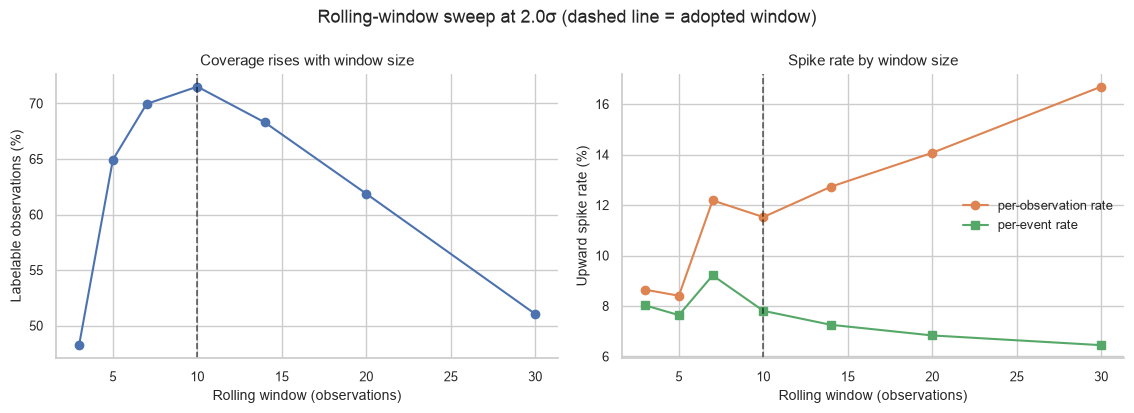

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].plot(sweep.index, sweep["labelable_%"], marker="o", color=PALETTE[0])
axes[0].set_xlabel("Rolling window (observations)")
axes[0].set_ylabel("Labelable observations (%)")
axes[0].set_title("Coverage rises with window size")
axes[0].axvline(SPIKE_WINDOW, ls="--", lw=1.2, color="black", alpha=0.6)

axes[1].plot(sweep.index, sweep["obs_rate_%"], marker="o", color=PALETTE[1],
             label="per-observation rate")
axes[1].plot(sweep.index, sweep["event_rate_%"], marker="s", color=PALETTE[2],
             label="per-event rate")
axes[1].set_xlabel("Rolling window (observations)")
axes[1].set_ylabel("Upward spike rate (%)")
axes[1].set_title("Spike rate by window size")
axes[1].axvline(SPIKE_WINDOW, ls="--", lw=1.2, color="black", alpha=0.6)
axes[1].legend(frameon=False)

fig.suptitle(f"Rolling-window sweep at {SPIKE_SIGMA}σ (dashed line = adopted window)")
fig.tight_layout()
save_fig(fig, "02_window_sweep")
plt.show()

Coverage climbs steeply to about ten observations and then flattens, while the spike rate
drifts upward as the window lengthens — a longer baseline is more easily exceeded once a
fare has stepped up. There is no window at which the rate stabilises at the low single-digit
figure a 2σ threshold would imply on a smooth series, which is the step structure asserting
itself.

**A window of 10 observations is adopted**, recorded as `SPIKE_WINDOW` in `config.py`. It
sits at the point where coverage has essentially saturated (~72% of rows) without extending
the baseline further than the median trajectory length of 9 observations, and it corresponds
to roughly ten calendar days given the near-daily cadence established in §2.

## 6. Events versus states

A single fare increase leaves the fare elevated relative to a trailing window for several
subsequent observations. Labelling each of those as a spike would count one price change many
times, and would train a model to recognise *"this fare is currently high"* rather than
*"this fare is about to jump"* — which is not what research question 2 asks.

In [11]:
stats = add_rolling_stats(df, window=SPIKE_WINDOW, min_periods=SPIKE_MIN_PERIODS)
labelled = label_spikes(stats, sigma=SPIKE_SIGMA, direction="up")

n_label = int(labelled.isLabelable.sum())
print(f"labelable observations : {n_label:,}  ({n_label/len(labelled):.1%} of rows)")
print(f"spike-labelled rows    : {int(labelled.isSpike.sum()):,}")
print(f"distinct spike events  : {int(labelled.isSpikeEvent.sum()):,}")
print(f"observations per event : {labelled.isSpike.sum()/labelled.isSpikeEvent.sum():.2f}")
print()
print(f"per-observation rate   : {labelled.isSpike.mean()*100:.2f}%  of all rows"
      f"   |  {labelled.isSpike.sum()/n_label*100:.2f}% of labelable")
print(f"per-event rate         : {labelled.isSpikeEvent.mean()*100:.2f}%  of all rows"
      f"   |  {labelled.isSpikeEvent.sum()/n_label*100:.2f}% of labelable")

labelable observations : 1,389,510  (71.5% of rows)
spike-labelled rows    : 160,121
distinct spike events  : 108,495
observations per event : 1.48

per-observation rate   : 8.24%  of all rows   |  11.52% of labelable
per-event rate         : 5.58%  of all rows   |  7.81% of labelable


Roughly **one in three spike-labelled observations is a continuation of a spike already under
way**, not a new one. `isSpikeEvent` — the first observation of each run — is therefore
adopted as the modelling target, and `isSpike` is retained only for comparison.

## 7. Sensitivity to the threshold

σ was fixed at 2.0 during the research phase, following Lee et al. (2024). Given that the
step structure inflates z-scores, the sensitivity of the rate to that choice should be
reported rather than left implicit.

In [12]:
# How sensitive is everything to the threshold we picked?
#
# We settled on 2 standard deviations, following the paper the rule came from.
# That was a borrowed choice, so here we simply try 1.5, 2, 2.5, 3 and 4 and
# report what each would have given. Being able to show this table is the
# difference between 'we chose 2' and 'we chose 2 and know what it costs'.
sigma_rows = []
for s in (1.5, 2.0, 2.5, 3.0, 4.0):
    lab = label_spikes(stats, sigma=s, direction="up")
    n = int(lab.isLabelable.sum())
    sigma_rows.append({
        "sigma": s,
        "spike_obs": int(lab.isSpike.sum()),
        "spike_events": int(lab.isSpikeEvent.sum()),
        "obs_rate_%": lab.isSpike.sum()/n*100,
        "event_rate_%": lab.isSpikeEvent.sum()/n*100,
        "imbalance_ratio": (n - lab.isSpikeEvent.sum()) / max(int(lab.isSpikeEvent.sum()), 1),
    })

sigma_table = pd.DataFrame(sigma_rows).set_index("sigma").round(2)
sigma_table

,spike_obs,spike_events,obs_rate_%,event_rate_%,imbalance_ratio
sigma,,,,,
1.5,256749,135257,18.48,9.73,9.27
2.0,160121,108495,11.52,7.81,11.81
2.5,114557,89461,8.24,6.44,14.53
3.0,72116,66771,5.19,4.81,19.81
4.0,49192,47160,3.54,3.39,28.46


The rate falls steeply with σ, as expected. The documented 2σ definition is retained — it is
the decision recorded in the methodology and it yields a workable event rate — but the table
above is the honest basis for that choice, and shows what a stricter threshold would produce
if the definition is revisited.

## 8. Where and when spikes occur

Two breakdowns matter for the modelling that follows: whether the two route types spike at
different rates, and how spike likelihood varies with the booking horizon.

In [13]:
by_route = spike_summary(labelled, by="route").round(2)
by_route

,rows,labelable,labelable_%,spike_obs,spike_events,obs_rate_%,event_rate_%
route,,,,,,,
BOS-LGA,433162.0,304645.0,70.33,44123.0,29266.0,14.48,9.61
JFK-LAX,547979.0,400366.0,73.06,38011.0,26162.0,9.49,6.53
LAX-JFK,566808.0,407608.0,71.91,37712.0,26502.0,9.25,6.50
LGA-BOS,395133.0,276891.0,70.08,40275.0,26565.0,14.55,9.59


In [14]:
# Where in the booking window do spikes actually happen?
#
# Note we filter to isLabelable first. Rows we could not judge would otherwise
# be counted as 'no spike', which would water down every rate below.
#
# This produces the 16.0% vs 5.2% figure quoted in the dissertation, and it
# independently confirms the decision to drop late departures: spikes cluster
# in the final days, which is exactly the period those flights never had.
lab_only = labelled[labelled.isLabelable].copy()
lab_only["horizon"] = pd.cut(
    lab_only.daysBeforeDeparture, horizon_bins, labels=horizon_labels, right=True
)

horizon = lab_only.groupby("horizon", observed=True).agg(
    labelable=("isSpikeEvent", "size"),
    events=("isSpikeEvent", "sum"),
)
horizon["event_rate_%"] = (horizon.events / horizon.labelable * 100).round(2)
horizon

,labelable,events,event_rate_%
horizon,,,
1-3,109508,17545,16.02
4-7,142816,16103,11.28
8-14,238412,20765,8.71
15-21,220558,16066,7.28
22-30,242110,12652,5.23
31-45,322965,18223,5.64
46-60,113141,7141,6.31


saved -> reports/figures/02_spike_rate_by_horizon_and_route.png


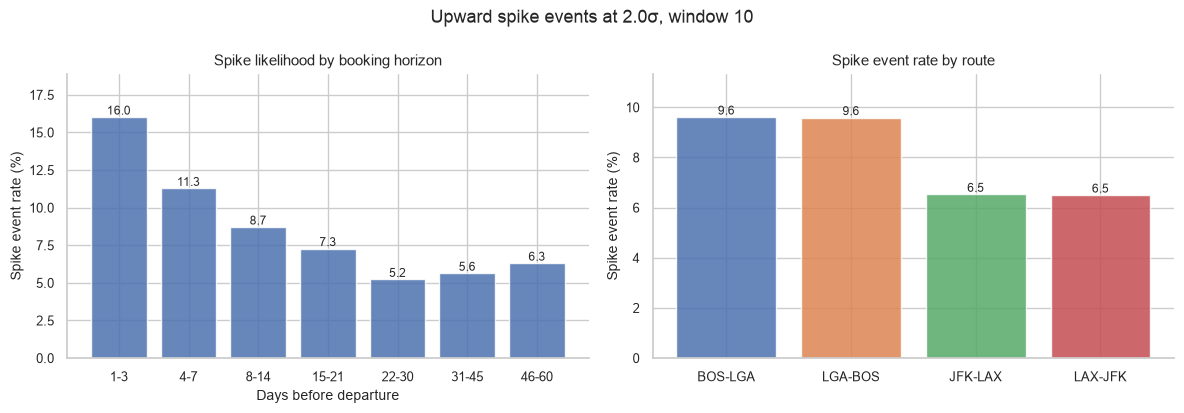

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# spike rate by booking horizon
axes[0].bar(horizon.index.astype(str), horizon["event_rate_%"], color=PALETTE[0], alpha=0.85)
axes[0].set_xlabel("Days before departure")
axes[0].set_ylabel("Spike event rate (%)")
axes[0].set_title("Spike likelihood by booking horizon")
for i, v in enumerate(horizon["event_rate_%"]):
    axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8.5)
axes[0].margins(y=0.18)

# spike rate by route
order = by_route.sort_values("event_rate_%", ascending=False).index.tolist()
axes[1].bar(order, by_route.loc[order, "event_rate_%"],
            color=[PALETTE[i % len(PALETTE)] for i in range(len(order))], alpha=0.85)
axes[1].set_ylabel("Spike event rate (%)")
axes[1].set_title("Spike event rate by route")
for i, r in enumerate(order):
    axes[1].text(i, by_route.loc[r, "event_rate_%"], f"{by_route.loc[r,'event_rate_%']:.1f}",
                 ha="center", va="bottom", fontsize=8.5)
axes[1].margins(y=0.18)

fig.suptitle(f"Upward spike events at {SPIKE_SIGMA}σ, window {SPIKE_WINDOW}")
fig.tight_layout()
save_fig(fig, "02_spike_rate_by_horizon_and_route")
plt.show()

### 8.1 The censoring exclusion, validated

The booking-horizon breakdown independently confirms the sample restriction inherited from
notebook 01, which until now rested on a theoretical argument about where revenue-management
surges occur.

**Spike likelihood is strongly concentrated near departure**: 16.0% in the final three days
against 5.2% at 22–30 days — roughly a threefold difference. Censored flights are those never
observed within 27 days of departure, which is precisely the region carrying the highest
spike rate. Including them would have diluted the positive class with flights structurally
incapable of contributing one, and the resulting spike rate would have understated the true
figure rather than merely adding noise.

The rate also ticks up slightly at the longest horizons (6.3% at 46–60 days), which is
consistent with early-release fare adjustments settling before the booking window matures.

**By route**, the short-haul shuttle routes spike about 50% more often than the
transcontinental ones (9.6% versus 6.5%). Taken with the steep short-haul booking curve in
§3, this points to more active revenue management on high-frequency business routes — another
long-haul/short-haul contrast for research question 3.

## 9. Class imbalance — the Section 7 decision

The research phase deferred the choice between SMOTE, ADASYN and undersampling explicitly
until a real minority-class count existed, on the reasoning that oversampling suits
minority classes numbering in the dozens while hybrid or undersampling approaches perform
comparably or better once counts reach the hundreds.

That count now exists, and it is far larger than either branch of that guidance anticipated.

In [16]:
n_label = int(labelled.isLabelable.sum())
n_event = int(labelled.isSpikeEvent.sum())

print(f"labelable observations : {n_label:,}")
print(f"minority class (events): {n_event:,}")
print(f"majority class         : {n_label - n_event:,}")
print(f"imbalance ratio        : 1 : {(n_label - n_event)/n_event:.1f}")
print()
print("minority-class count per route:")
print(labelled[labelled.isLabelable].groupby("route", observed=True)["isSpikeEvent"].sum().to_string())

labelable observations : 1,389,510
minority class (events): 108,495
majority class         : 1,281,015
imbalance ratio        : 1 : 11.8

minority-class count per route:
route
BOS-LGA    29266
JFK-LAX    26162
LAX-JFK    26502
LGA-BOS    26565


**The minority class numbers over one hundred thousand, at roughly a 1:12 ratio.** This is a
moderate imbalance, not a severe one, and it sits far outside the regime the research-phase
guidance addressed — that guidance distinguished counts in the *dozens* from counts in the
*hundreds*.

Synthetic oversampling is not indicated here. SMOTE and ADASYN exist to manufacture signal
when a minority class is too small to learn from; with more than 100,000 positive examples
per the full sample and five figures per route, that problem does not arise. Generating
synthetic neighbours would add computational cost and — as the research phase already noted —
distort temporal ordering, in exchange for solving a scarcity problem the data does not have.

**Recommended approach, in order:**

1. **An unweighted baseline first**, so the imbalance cost is measured rather than assumed.
2. **Class weighting** — `scale_pos_weight` for XGBoost, `class_weight="balanced"` for
   scikit-learn estimators, a weighted loss for the LSTM. This addresses a 1:12 ratio
   directly, costs nothing computationally, and introduces no synthetic observations into a
   time series.
3. **Threshold tuning on the decision boundary**, selected on validation folds against F1 —
   which typically recovers more on moderate imbalance than resampling does.

Resampling should be revisited only if per-route or per-fold minority counts turn out to be
much thinner than the aggregate suggests. This is a change to the plan recorded in the
research phase, made on evidence rather than assumption, and it should be stated as such in
the methodology chapter.

## 10. Persist the labelled dataset

In [17]:
out_cols = [
    "legId", "searchDate", "flightDate", "route", "startingAirport", "destinationAirport",
    "daysBeforeDeparture", "totalFare", "baseFare", "seatsRemaining", "isNonStop",
    "isBasicEconomy", "isRefundable", "travelDuration", "totalTravelDistance",
    "segmentsAirlineName", "segmentsDepartureTimeRaw",
    "rollMean", "rollStd", "spikeZ", "isLabelable", "isSpike", "isSpikeEvent",
]
out = labelled[out_cols]

out_path = PROCESSED_DIR / "spikes_labelled.parquet"
out.to_parquet(out_path, index=False)

print(f"wrote {len(out):,} rows x {len(out.columns)} cols -> {out_path.name} "
      f"({out_path.stat().st_size/1e6:.1f} MB)")

wrote 1,943,082 rows x 23 cols -> spikes_labelled.parquet (45.4 MB)


## Summary

| | |
|---|---|
| Sample | departures ≤ 2022-10-12 (right-censoring cutoff) |
| Rows / flights | 1,943,082 / 106,700 |
| Trajectory unit | `legId` — one row per (flight, search date), no flight spans two departures |
| Cadence | 85.8% of consecutive searches exactly 1 day apart |
| Rolling window | **10 observations**, `min_periods` 5, causal (excludes current observation) |
| Threshold | 2σ, retained from the research phase, sensitivity reported |
| Target | `isSpikeEvent` — run starts, not sustained states |

**Established here:**

- **Flight fares are step functions, not continuous series.** 62% of consecutive observations
  repeat the previous fare; a typical flight shows 4 distinct fares across 9 observations.
  This is a real difference from the commodity-price literature the 2σ rule was adapted from,
  and it inflates z-scores because σ collapses inside a flat run. It belongs in the
  methodology as a stated limitation of the transferred definition.
- **The 20-observation window inherited from Lee et al. (2024) was not appropriate** — it
  would have been unusable for 65% of flights, whose median trajectory is 9 observations.
  A window of 10 was chosen on coverage and trajectory length.
- **Spikes must be labelled as events, not states.** One in three naive spike labels is a
  continuation of a spike already under way.
- **Class imbalance is moderate (≈1:12), not severe.** This overturns the assumption behind
  the deferred SMOTE/ADASYN decision — synthetic oversampling is not indicated, and class
  weighting is the appropriate response.
- **The booking curve is route-dependent.** Short-haul fares rise ~65% into departure while
  long-haul fares are near flat, so "fares rise as departure approaches" cannot be stated as
  a general property of this dataset. Days-before-departure will carry very different weight
  by route, reinforcing the day-of-week finding from notebook 01.
- **The censoring exclusion is empirically justified, not just theoretically.** Spike rate
  runs at 16.0% in the final three days against 5.2% at 22–30 days, so the excluded flights
  were exactly those unable to be observed in the highest-spike window.

**Next:** `03_feature_engineering.ipynb` — build the feature set from Section 4 of the
project notes (days before departure, day of week, non-stop, holiday flag, summer proxy) on
top of this labelled frame. Before any model is built, the validation strategy still has to
be settled: rolling-origin versus a single chronological split remains undecided, and
García Crespi et al. (2026) found model rankings can reverse between the two.